In [3]:
!pip install ctgan
!pip install sdv  # Optional, for additional utilities

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 668.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━

Gen. (-0.16) | Discrim. (-0.34): 100%|██████████| 100/100 [05:05<00:00,  3.06s/it]


KS Test for Delegations_Latitude: Statistic=0.0038, P-value=0.9864
Chi-Squared Test for GOUVERNORAT: Statistic=3.8101, P-value=1.0000


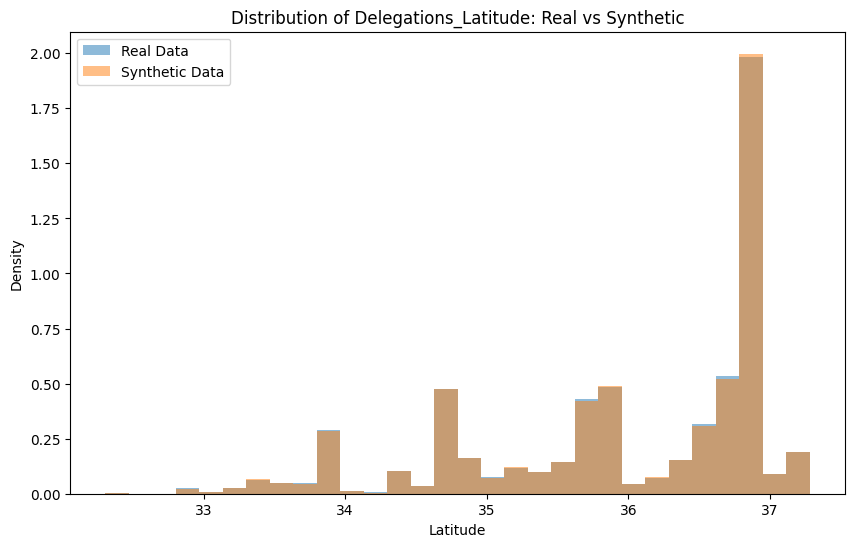

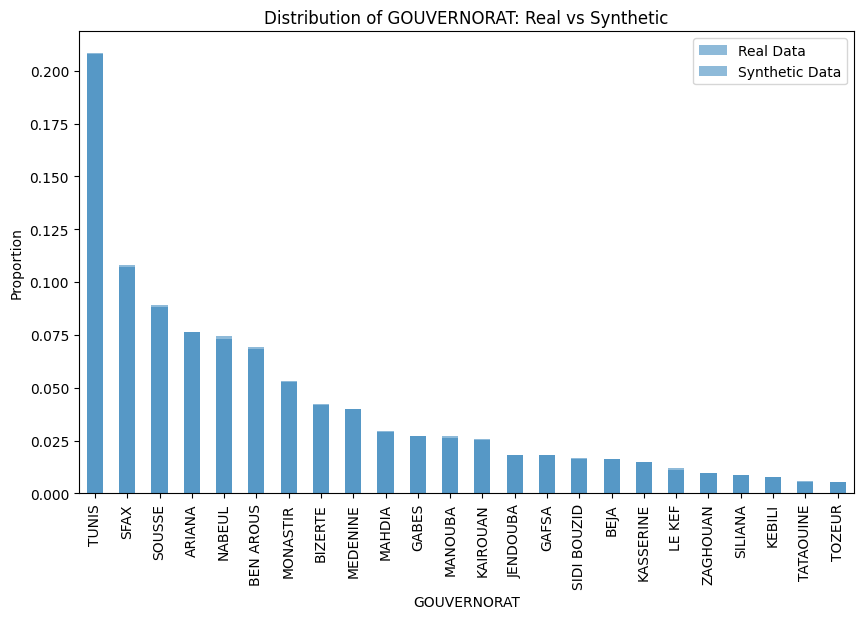

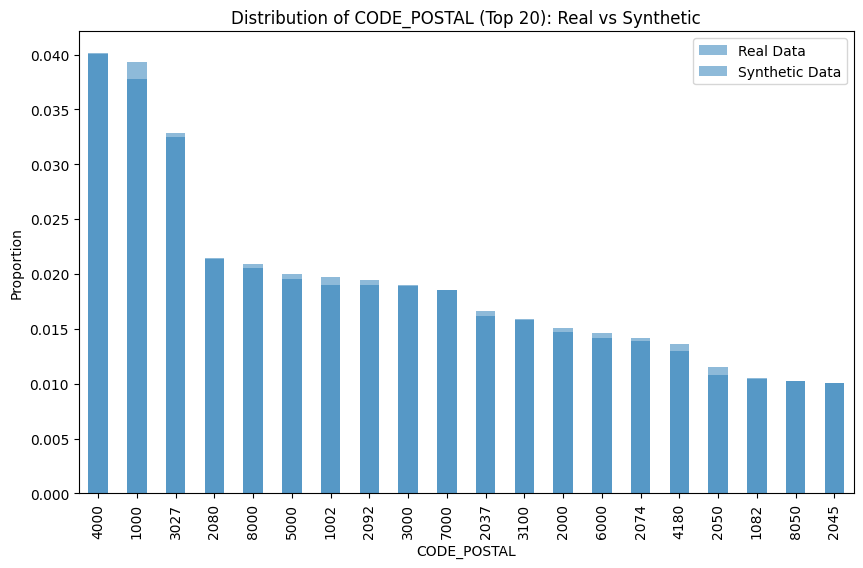

Number of duplicate rows: 0
FullName: 49917 unique values, 0.17% duplicates
NOM: 6475 unique values, 87.05% duplicates
PRENOM: 2768 unique values, 94.46% duplicates
ADRESSE: 15553 unique values, 68.89% duplicates
CODE_POSTAL: 517 unique values, 98.97% duplicates
LOCALITE: 516 unique values, 98.97% duplicates
GOUVERNORAT: 24 unique values, 99.95% duplicates
SPECIALITE: 53 unique values, 99.89% duplicates
CATEGORIE_PRESTATAIRE: 35 unique values, 99.93% duplicates
APC: 2 unique values, 100.00% duplicates
NameAr: 24 unique values, 99.95% duplicates
Delegations_Name: 517 unique values, 98.97% duplicates
Delegations_NameAr: 517 unique values, 98.97% duplicates
Delegations_Value: 253 unique values, 99.49% duplicates
Delegations_Latitude: 285 unique values, 99.43% duplicates
Delegations_Longitude: 277 unique values, 99.45% duplicates


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
from ctgan import CTGAN
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, chi2_contingency

# Load the Dataset with UTF-8 encoding
df = pd.read_csv("/kaggle/input/medecines/medecines_locations.csv", encoding='utf-8')

# Step 1: Preprocess Data
# Rename columns for consistency
df = df.rename(columns={
    'Delegations.Name': 'Delegations_Name',
    'Delegations.NameAr': 'Delegations_NameAr',
    'Delegations.Value': 'Delegations_Value',
    'Delegations.Latitude': 'Delegations_Latitude',
    'Delegations.Longitude': 'Delegations_Longitude'
})

# Convert categorical columns to strings
categorical_columns = [
    'CODE_POSTAL', 'LOCALITE', 'GOUVERNORAT', 'SPECIALITE', 'CATEGORIE_PRESTATAIRE', 
    'APC', 'NameAr', 'Delegations_Name', 'Delegations_NameAr', 'Delegations_Value'
]
for col in categorical_columns:
    df[col] = df[col].astype(str)

# Ensure numerical columns are floats
numerical_columns = ['Delegations_Latitude', 'Delegations_Longitude']
for col in numerical_columns:
    df[col] = df[col].astype(float)

# Handle missing values
df['CODE_POSTAL'] = df['CODE_POSTAL'].fillna(df['CODE_POSTAL'].mode()[0])
df['LOCALITE'] = df['LOCALITE'].fillna('Unknown')
df['GOUVERNORAT'] = df['GOUVERNORAT'].fillna('Unknown')
df['SPECIALITE'] = df['SPECIALITE'].fillna('Unknown')
df['CATEGORIE_PRESTATAIRE'] = df['CATEGORIE_PRESTATAIRE'].fillna('Unknown')
df['APC'] = df['APC'].fillna('NON')
df['Delegations_Name'] = df['Delegations_Name'].fillna('Unknown')
df['Delegations_NameAr'] = df['Delegations_NameAr'].fillna('غير معروف')
df['Delegations_Value'] = df['Delegations_Value'].fillna('Unknown')
df['Delegations_Latitude'] = df['Delegations_Latitude'].fillna(df['Delegations_Latitude'].median())
df['Delegations_Longitude'] = df['Delegations_Longitude'].fillna(df['Delegations_Longitude'].median())
df['NameAr'] = df['NameAr'].fillna('غير معروف')
df['FullName'] = df['FullName'].fillna('Unknown')
df['NOM'] = df['NOM'].fillna('Unknown')
df['PRENOM'] = df['PRENOM'].fillna('Unknown')
df['ADRESSE'] = df['ADRESSE'].fillna('Unknown')

# Remove duplicates
df = df.drop_duplicates()

# Create pools for Tunisian names, specialties, and provider categories
nom_pool = df['NOM'].dropna().unique()
prenom_pool = df['PRENOM'].dropna().unique()
specialite_pool = df['SPECIALITE'].dropna().unique()
categorie_prestataire_pool = df['CATEGORIE_PRESTATAIRE'].dropna().unique()

# Calculate probability distributions for sampling
specialite_probs = df['SPECIALITE'].value_counts(normalize=True)
categorie_prestataire_probs = df['CATEGORIE_PRESTATAIRE'].value_counts(normalize=True)

# Create lookup table for CODE_POSTAL and related columns
postal_lookup = df.groupby('CODE_POSTAL').agg({
    'ADRESSE': lambda x: list(x.unique()),
    'GOUVERNORAT': 'first',
    'LOCALITE': lambda x: list(x.unique()),
    'Delegations_Name': lambda x: list(x.unique()),
    'Delegations_NameAr': lambda x: list(x.unique()),
    'Delegations_Value': lambda x: list(x.unique()),
    'Delegations_Latitude': 'first',
    'Delegations_Longitude': 'first'
}).to_dict('index')
code_postal_probs = df['CODE_POSTAL'].value_counts(normalize=True)

# Define columns to model (exclude PII: FullName, NOM, PRENOM, ADRESSE, NameAr)
columns_to_model = [
    'CODE_POSTAL', 'LOCALITE', 'GOUVERNORAT', 'SPECIALITE', 'CATEGORIE_PRESTATAIRE', 
    'APC', 'Delegations_Name', 'Delegations_NameAr', 'Delegations_Value', 
    'Delegations_Latitude', 'Delegations_Longitude'
]
discrete_columns = [
    'CODE_POSTAL', 'LOCALITE', 'GOUVERNORAT', 'SPECIALITE', 'CATEGORIE_PRESTATAIRE', 
    'APC', 'Delegations_Name', 'Delegations_NameAr', 'Delegations_Value'
]

# Create subset for modeling
df_model = df[columns_to_model]

# Step 2: Train CTGAN
ctgan = CTGAN(
    epochs=100,
    batch_size=200,
    verbose=True
)
ctgan.fit(df_model, discrete_columns=discrete_columns)

# Step 3: Generate Synthetic Data
num_rows = 50000
synthetic_data = ctgan.sample(num_rows)

# Step 4: Add PII Columns and Enforce Constraints
# Generate Tunisian names
synthetic_data['NOM'] = np.random.choice(nom_pool, size=num_rows)
synthetic_data['PRENOM'] = np.random.choice(prenom_pool, size=num_rows)
synthetic_data['FullName'] = [f"{prenom} {nom}" for prenom, nom in zip(synthetic_data['PRENOM'], synthetic_data['NOM'])]
synthetic_data['NameAr'] = np.random.choice(df['NameAr'].dropna().unique(), size=num_rows)

# Sample SPECIALITE and CATEGORIE_PRESTATAIRE based on real distributions
synthetic_data['SPECIALITE'] = np.random.choice(
    specialite_pool, size=num_rows, p=specialite_probs[specialite_pool]
)
synthetic_data['CATEGORIE_PRESTATAIRE'] = np.random.choice(
    categorie_prestataire_pool, size=num_rows, p=categorie_prestataire_probs[categorie_prestataire_pool]
)

# Enforce APC rule: APC = "APC" if CATEGORIE_PRESTATAIRE contains "APC", else "NON"
apc_values = df['APC'].dropna().unique()
non_apc_value = 'NON' if 'NON' in apc_values else apc_values[0]
synthetic_data['APC'] = synthetic_data['CATEGORIE_PRESTATAIRE'].apply(
    lambda x: 'APC' if 'APC' in x.upper() else non_apc_value
)

# Enforce strict consistency for CODE_POSTAL and related columns
for idx in synthetic_data.index:
    # Sample CODE_POSTAL based on real distribution
    postal_code = np.random.choice(code_postal_probs.index, p=code_postal_probs.values)
    if postal_code in postal_lookup:
        lookup = postal_lookup[postal_code]
        synthetic_data.at[idx, 'CODE_POSTAL'] = postal_code
        synthetic_data.at[idx, 'ADRESSE'] = np.random.choice(lookup['ADRESSE'])
        synthetic_data.at[idx, 'GOUVERNORAT'] = lookup['GOUVERNORAT']
        synthetic_data.at[idx, 'LOCALITE'] = np.random.choice(lookup['LOCALITE'])
        synthetic_data.at[idx, 'Delegations_Name'] = np.random.choice(lookup['Delegations_Name'])
        synthetic_data.at[idx, 'Delegations_NameAr'] = np.random.choice(lookup['Delegations_NameAr'])
        synthetic_data.at[idx, 'Delegations_Value'] = np.random.choice(lookup['Delegations_Value'])
        synthetic_data.at[idx, 'Delegations_Latitude'] = lookup['Delegations_Latitude']
        synthetic_data.at[idx, 'Delegations_Longitude'] = lookup['Delegations_Longitude']

# Reorder columns
synthetic_data = synthetic_data[[
    'FullName', 'NOM', 'PRENOM', 'ADRESSE', 'CODE_POSTAL', 'LOCALITE', 'GOUVERNORAT', 
    'SPECIALITE', 'CATEGORIE_PRESTATAIRE', 'APC', 'NameAr', 'Delegations_Name', 
    'Delegations_NameAr', 'Delegations_Value', 'Delegations_Latitude', 'Delegations_Longitude'
]]

# Step 5: Save Synthetic Data with UTF-8 encoding
synthetic_data.to_csv('/kaggle/working/synthetic_medecines_locations_2.csv', index=False, encoding='utf-8')

# Step 6: Evaluate Synthetic Data
# Numerical: KS test for Delegations_Latitude
ks_stat, ks_pvalue = ks_2samp(df['Delegations_Latitude'], synthetic_data['Delegations_Latitude'])
print(f"KS Test for Delegations_Latitude: Statistic={ks_stat:.4f}, P-value={ks_pvalue:.4f}")

# Categorical: Chi-squared test for GOUVERNORAT
real_counts = df['GOUVERNORAT'].value_counts()
synth_counts = synthetic_data['GOUVERNORAT'].value_counts()
common_values = real_counts.index.intersection(synth_counts.index)
contingency_table = pd.DataFrame({
    'Real': real_counts[common_values],
    'Synthetic': synth_counts[common_values]
}).fillna(0)
chi2_stat, chi2_pvalue, _, _ = chi2_contingency(contingency_table)
print(f"Chi-Squared Test for GOUVERNORAT: Statistic={chi2_stat:.4f}, P-value={chi2_pvalue:.4f}")

# Visualizations
plt.figure(figsize=(10, 6))
plt.hist(df['Delegations_Latitude'], bins=30, alpha=0.5, label='Real Data', density=True)
plt.hist(synthetic_data['Delegations_Latitude'], bins=30, alpha=0.5, label='Synthetic Data', density=True)
plt.title('Distribution of Delegations_Latitude: Real vs Synthetic')
plt.xlabel('Latitude')
plt.ylabel('Density')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
df['GOUVERNORAT'].value_counts(normalize=True).plot(kind='bar', alpha=0.5, label='Real Data')
synthetic_data['GOUVERNORAT'].value_counts(normalize=True).plot(kind='bar', alpha=0.5, label='Synthetic Data')
plt.title('Distribution of GOUVERNORAT: Real vs Synthetic')
plt.xlabel('GOUVERNORAT')
plt.ylabel('Proportion')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
df['CODE_POSTAL'].value_counts(normalize=True).head(20).plot(kind='bar', alpha=0.5, label='Real Data')
synthetic_data['CODE_POSTAL'].value_counts(normalize=True).head(20).plot(kind='bar', alpha=0.5, label='Synthetic Data')
plt.title('Distribution of CODE_POSTAL (Top 20): Real vs Synthetic')
plt.xlabel('CODE_POSTAL')
plt.ylabel('Proportion')
plt.legend()
plt.show()

# Duplicate analysis
print(f"Number of duplicate rows: {synthetic_data.duplicated().sum()}")
for col in synthetic_data.columns:
    unique_count = synthetic_data[col].nunique()
    duplicate_pct = (num_rows - unique_count) / num_rows * 100
    print(f"{col}: {unique_count} unique values, {duplicate_pct:.2f}% duplicates")

# Save the CTGAN model
ctgan.save('/kaggle/working/ctgan_model.pkl')

In [7]:
import pandas as pd

# Load both files (try correct encoding for Arabic)
df1 = pd.read_csv('/kaggle/input/medical/medecines_locations.csv', encoding='utf-8')
df2 = pd.read_csv('/kaggle/input/medical/synthetic_medecines_locations_2.csv', encoding='utf-8')

# If Arabic still looks garbled, try this instead:
# df1 = pd.read_csv('...', encoding='windows-1256')
# df2 = pd.read_csv('...', encoding='windows-1256')

# Merge the datasets (stack them vertically)
merged_df = pd.concat([df1, df2], ignore_index=True)

# Save the merged file
merged_df.to_csv('/kaggle/working/merged_medecines_1.csv', index=False, encoding='utf-8')

print("✅ Merged successfully! Rows:", len(merged_df))


✅ Merged successfully! Rows: 69130
